In [23]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
## Working with tools 
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv and Wikipedia tools 
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)


In [25]:
wiki_tool.invoke("Who is Sharukh khan")

'Page: Shah Rukh Khan\nSummary: Shah Rukh Khan (pronounced [ˈʃaːɦɾʊx xäːn] ; born 2 November 1965), also known by the initialism SRK, is an Indian actor and film producer who works in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Khan", he has appeared in more than 10'

In [26]:
arxiv_tool.invoke("Attention is all you need")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with "

In [27]:
tools=[wiki_tool,arxiv_tool]

In [28]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [29]:
graph_builder=StateGraph(State)


In [30]:
from langchain_groq import ChatGroq
llm=ChatGroq(groq_api_key=os.getenv('GROQ_API_KEY'),model="Gemma2-9b-It")
llm_with_tools=llm.bind_tools(tools=tools)


In [31]:
def chatbot(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


In [32]:
from langgraph.prebuilt import ToolNode,tools_condition

In [33]:
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge("chatbot",END)

In [34]:
graph=graph_builder.compile()

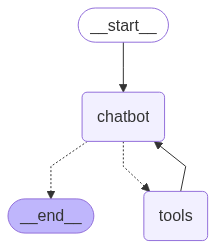

In [35]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:

    pass

In [40]:
user_input="Tell me about Attention is all you need from arxiv"
events=graph.stream(
    {"messages":[("user",user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Tell me about Attention is all you need from arxiv
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_ezfq)
 Call ID: call_ezfq
  Args:
    query: Attention is all you need
================================= Tool Message =================================
Name: arxiv

Published: 2024-07-22
Title: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models
Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini
Summary: The inference demand for LLMs has skyrocketed in recent months, and serving
models with 
================================== Ai Message ==================================

This paper discusses the power demands of large language models and suggests ways to reduce them for inference tasks.
